### Exploring Netflix data.

In [1]:
#Librarise
using FloatingTableView
using AlgebraOfGraphics 
using CategoricalArrays
using DataFramesMeta
using CairoMakie
using Statistics
using DataFrames 
using Printf
using Dates 
using Plots
using XLSX
using GLM

ArgumentError: ArgumentError: Package DataFramesMeta not found in current path.
- Run `import Pkg; Pkg.add("DataFramesMeta")` to install the DataFramesMeta package.

The first step is consuming in the data given they are in multiple files and have different names.

In [2]:
#all this are helper functions to get the data - of course the exploration will be 2 fold.
#Get all teh excel files.
function getExcelFiles(directoryPath)    
    allFiles = readdir(directoryPath)    
    excelFiles = filter(file -> occursin(r"\.xlsx?$"i, file), allFiles)
    fullPaths = [joinpath(directoryPath, file) for file in excelFiles]    
    return fullPaths
end


function findMatchingSheet(sheetNames,patterns,defaultSheet)    
    #Try case insensitive matches.
    lowerSheetNames = lowercase.(sheetNames)
    for pattern in patterns
        lowerPattern = lowercase(pattern)
        if lowerPattern in lowerSheetNames
            idx = findfirst(x -> lowercase(x) == lowerPattern, sheetNames)
            return sheetNames[idx]
        end
    end
            
    if defaultSheet in sheetNames
        return defaultSheet
    end
    
    return nothing
end


#reading multi files into one df
function readExcelFilesIntoDf(filePaths;possibleSheetNames=["Movies", "Film"])
    combinedDf = DataFrame()
    
    for filePath in filePaths
        sheetNames = XLSX.sheetnames(XLSX.readxlsx(filePath))
        targetSheetIndex = findfirst(s -> lowercase(s) in lowercase.(possibleSheetNames), sheetNames)

        try                     
            targetSheet = sheetNames[targetSheetIndex]            
            df = DataFrame(XLSX.readtable(filePath,targetSheet,first_row=6,infer_eltypes=true))
            #Add source file information
            df[!, :sourceFile] .= basename(filePath)
            df[!, :filePath] .= filePath
            df[!, :sheetName] .= targetSheet
            
            #Combine with previous data
            combinedDf = isempty(combinedDf) ? df : vcat(combinedDf, df, cols=:union)
            
            println("Successfully read: $(basename(filePath))")
            
        catch e
            println("Error reading $(basename(filePath)): $e")
        end
    end
    
    return combinedDf
end

readExcelFilesIntoDf (generic function with 1 method)

### 1.) Data cleaning and consumption.

In [4]:
directoryPath = "D:\\Projects\\Julia Research Projects\\Netflix Analysis\\data"
filePaths = getExcelFiles(directoryPath)
combinedFilmsDf = readExcelFilesIntoDf(filePaths;possibleSheetNames=["Movies", "Film"])
combinedFilmsDf[!,:"Type"] .= "Film"

#Read in teh shows data.
combinedShowsDf = readExcelFilesIntoDf(filePaths;possibleSheetNames=["Shows","TV"])
combinedShowsDf[!,:"Type"] .= "Shows"

combinedNetflixData = vcat(combinedFilmsDf,combinedShowsDf)
first(combinedNetflixData,5)

Successfully read: What_We_Watched_A_Netflix_Engagement_Report_2023Jul-Dec.xlsx
Successfully read: What_We_Watched_A_Netflix_Engagement_Report_2024Jan-Jun.xlsx
Successfully read: What_We_Watched_A_Netflix_Engagement_Report_2024Jul-Dec.xlsx
Successfully read: What_We_Watched_A_Netflix_Engagement_Report_2025Jan-Jun.xlsx
Successfully read: What_We_Watched_A_Netflix_Engagement_Report_2023Jul-Dec.xlsx
Successfully read: What_We_Watched_A_Netflix_Engagement_Report_2024Jan-Jun.xlsx
Successfully read: What_We_Watched_A_Netflix_Engagement_Report_2024Jul-Dec.xlsx
Successfully read: What_We_Watched_A_Netflix_Engagement_Report_2025Jan-Jun.xlsx


Row,Title,Available Globally?,Release Date,Hours Viewed,Runtime,Views,sourceFile,filePath,sheetName,Type
,String,String,String?,Int64,String,Int64,String,String,String,String
1,Leave the World Behind,Yes,2023-12-08,286300000,2:22,121000000,What_We_Watched_A_Netflix_Engagement_Report_2023Jul-Dec.xlsx,D:\\Projects\\Julia Research Projects\\Netflix Analysis\\data\\What_We_Watched_A_Netflix_Engagement_Report_2023Jul-Dec.xlsx,Film,Film
2,Heart of Stone,Yes,2023-08-11,228400000,2:05,109600000,What_We_Watched_A_Netflix_Engagement_Report_2023Jul-Dec.xlsx,D:\\Projects\\Julia Research Projects\\Netflix Analysis\\data\\What_We_Watched_A_Netflix_Engagement_Report_2023Jul-Dec.xlsx,Film,Film
3,Leo,Yes,2023-11-21,171200000,1:47,96000000,What_We_Watched_A_Netflix_Engagement_Report_2023Jul-Dec.xlsx,D:\\Projects\\Julia Research Projects\\Netflix Analysis\\data\\What_We_Watched_A_Netflix_Engagement_Report_2023Jul-Dec.xlsx,Film,Film
4,Nowhere,Yes,2023-09-29,156600000,1:49,86200000,What_We_Watched_A_Netflix_Engagement_Report_2023Jul-Dec.xlsx,D:\\Projects\\Julia Research Projects\\Netflix Analysis\\data\\What_We_Watched_A_Netflix_Engagement_Report_2023Jul-Dec.xlsx,Film,Film
5,The Out-Laws,Yes,2023-07-07,135500000,1:37,83800000,What_We_Watched_A_Netflix_Engagement_Report_2023Jul-Dec.xlsx,D:\\Projects\\Julia Research Projects\\Netflix Analysis\\data\\What_We_Watched_A_Netflix_Engagement_Report_2023Jul-Dec.xlsx,Film,Film


In [5]:
#any necessary data cleaning procedure needed.
cleanData = dropmissing(combinedNetflixData, "Release Date")
#cleanData[!, :ReleaseDate] = Date.(cleanData[!, "Release Date"])
cleanData[!, :ReleaseDate] = Date.(cleanData[!, :"Release Date"], dateformat"yyyy-mm-dd")
first(cleanData,2)

Row,Title,Available Globally?,Release Date,Hours Viewed,Runtime,Views,sourceFile,filePath,sheetName,Type,ReleaseDate
,String,String,String,Int64,String,Int64,String,String,String,String,Date
1,Leave the World Behind,Yes,2023-12-08,286300000,2:22,121000000,What_We_Watched_A_Netflix_Engagement_Report_2023Jul-Dec.xlsx,D:\\Projects\\Julia Research Projects\\Netflix Analysis\\data\\What_We_Watched_A_Netflix_Engagement_Report_2023Jul-Dec.xlsx,Film,Film,2023-12-08
2,Heart of Stone,Yes,2023-08-11,228400000,2:05,109600000,What_We_Watched_A_Netflix_Engagement_Report_2023Jul-Dec.xlsx,D:\\Projects\\Julia Research Projects\\Netflix Analysis\\data\\What_We_Watched_A_Netflix_Engagement_Report_2023Jul-Dec.xlsx,Film,Film,2023-08-11


### 2.) Understanding viewership patterns

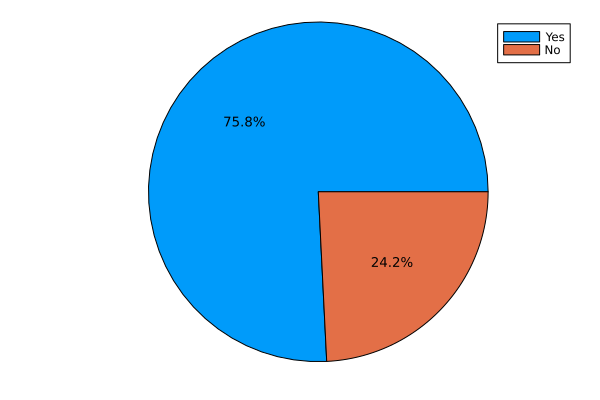

In [6]:
# 1.1) Analysis of global availability
globalAnalysis = combine(groupby(cleanData, :"Available Globally?"), :"Hours Viewed" => sum => :TotalHours,nrow => :Count)

data = globalAnalysis[:,:Count]
labels = globalAnalysis[:,:"Available Globally?"]
tot = sum(data)
datapct = [@sprintf("%.1f%%", x/tot*100) for x in data]

θ = (cumsum(data) - data/2) .* 360/sum(data)
scθ = sincosd.(θ)

p = Plots.pie(labels, data)
for (s, sci) in zip(datapct, scθ)
    annotate!(0.6*sci[2], 0.6*sci[1], Plots.text(s, 9, :black))
end
p

Most of the shows\films are all avaible globally meaning most are likely in english if not they have been translated.Unfortunately this is an assumption the language data wasn't realleased in the data.

In [7]:
# 1.2 viewership Yearly and quarterly analysis.
cleanData[!, :ReleaseYear] = year.(cleanData[!, :ReleaseDate])
cleanData[!, :ReleaseQuarter] = string.(year.(cleanData[!, :ReleaseDate]), "-Q", Dates.quarter.(cleanData[!, :ReleaseDate]))

yearlyAnalysis = combine(groupby(cleanData,[:ReleaseYear,:Type]), 
    :"Hours Viewed" => sum => :TotalHours,
    :"Hours Viewed" => mean => :AvgHoursPerTitle,
    nrow => :TitlesReleased)

quarterlyAnalysis = combine(groupby(cleanData, [:ReleaseQuarter,:Type]), 
    :"Hours Viewed" => sum => :TotalHours,
    nrow => :TitlesReleased)

first(quarterlyAnalysis,3)

Row,ReleaseQuarter,Type,TotalHours,TitlesReleased
,String,String,Int64,Int64
1,2023-Q4,Film,3463300000,281
2,2023-Q3,Film,3459500000,294
3,2023-Q2,Film,1421200000,205


### 1.) Total Hours Viewed (Billions)

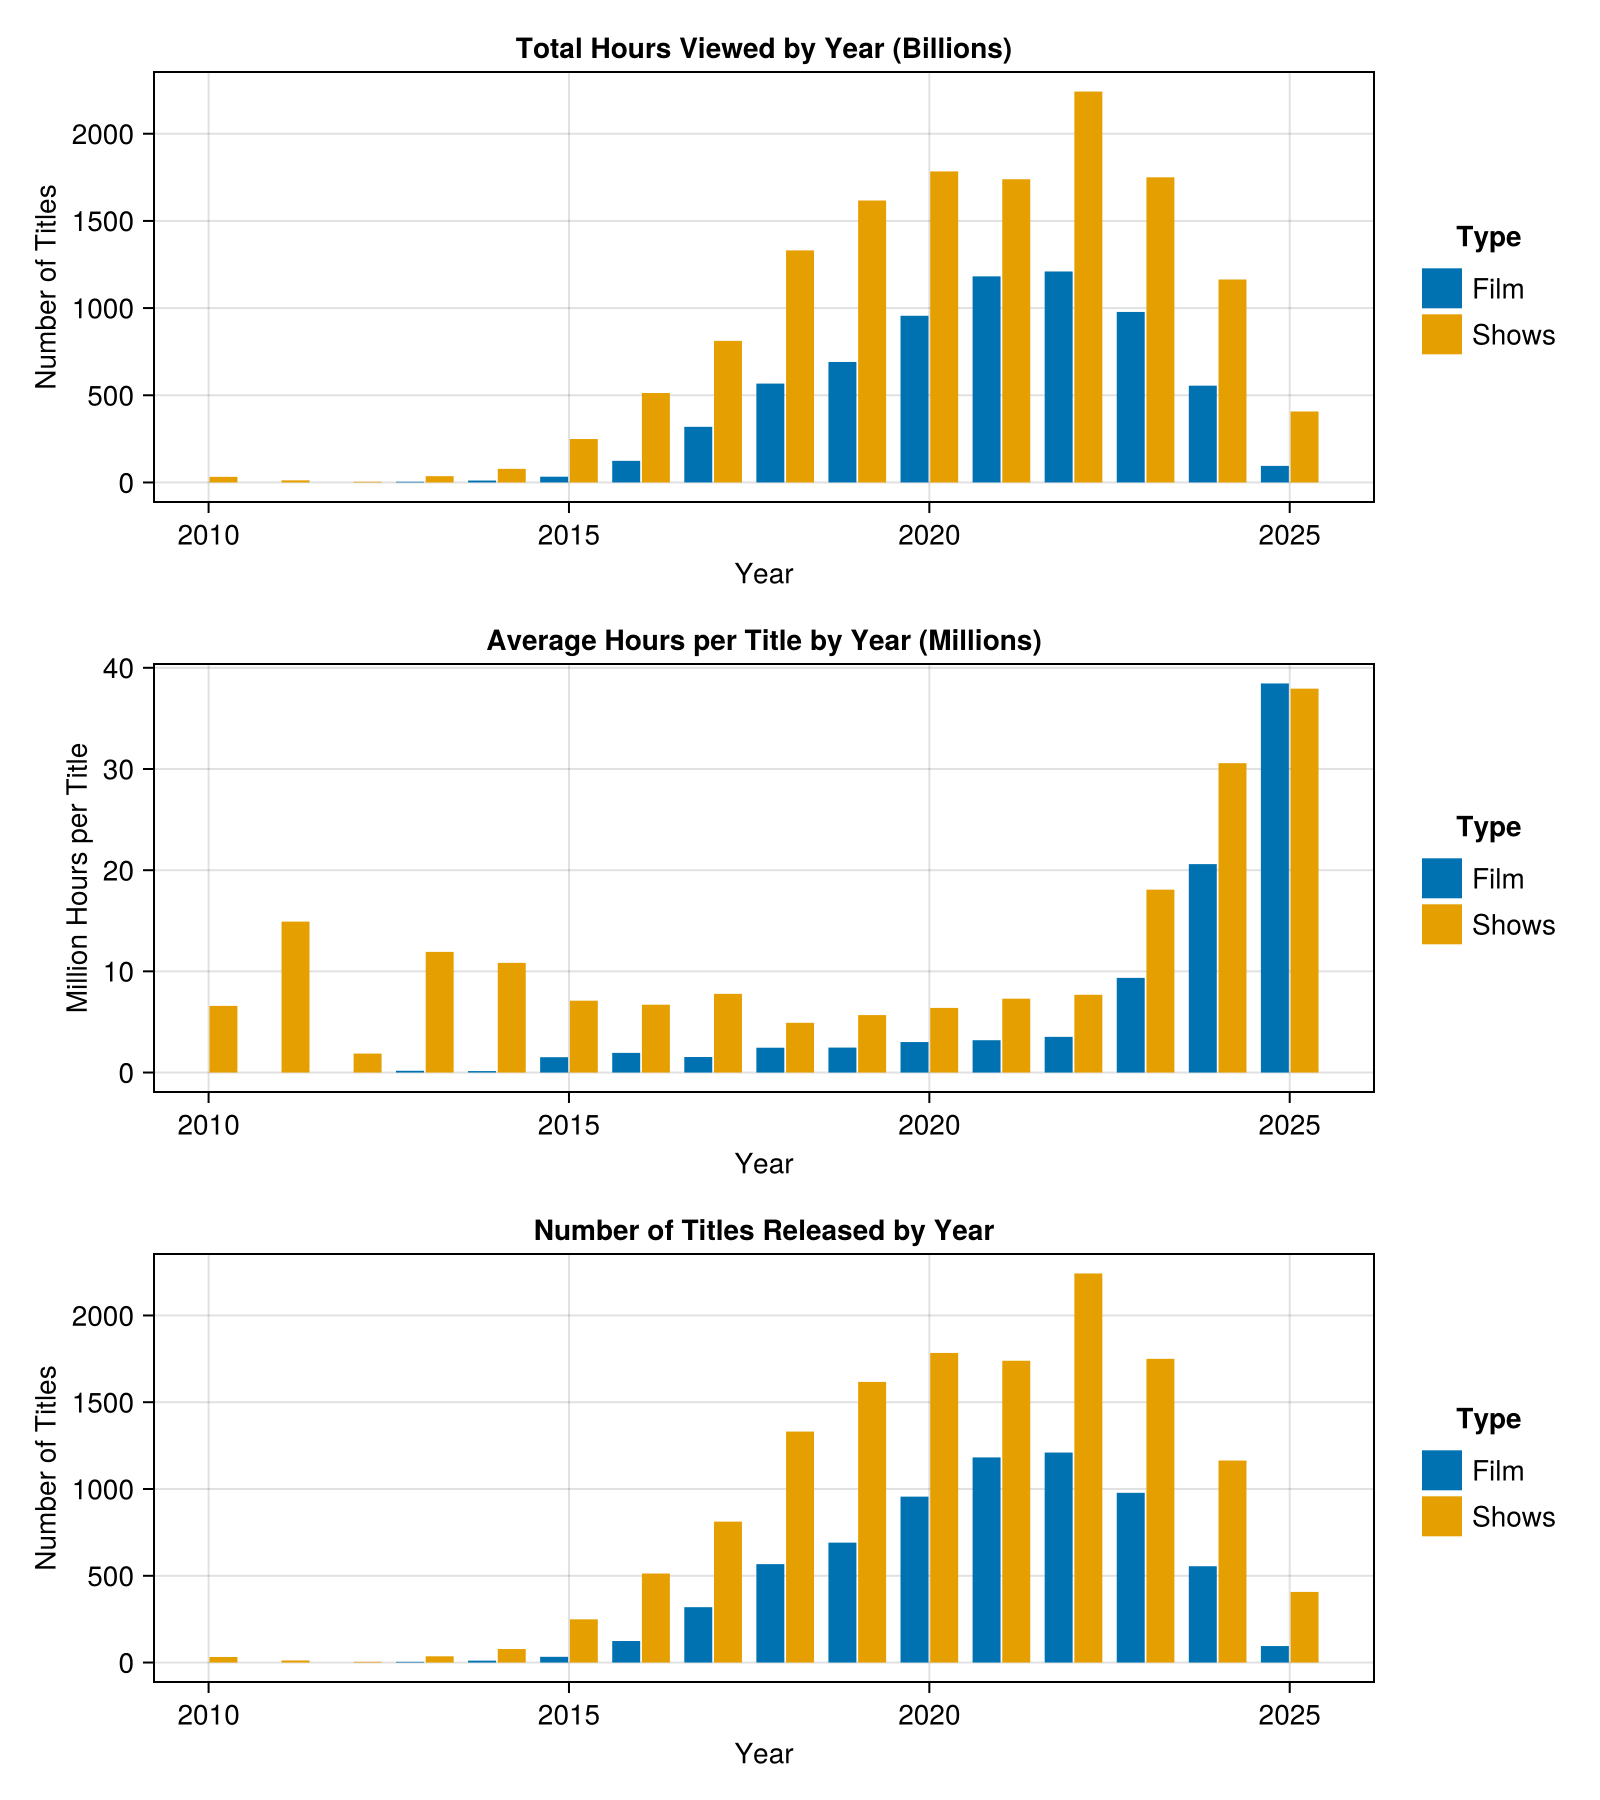

In [8]:
fig = Figure(size=(800, 900))
ax = Axis(fig[1, 1], 
          title = "Total Hours Viewed by Year (Billions)",
          xlabel="Year", ylabel="Number of Titles")

p1 = AlgebraOfGraphics.data(yearlyAnalysis) * mapping(
    :ReleaseYear, 
    :TitlesReleased,
    color = :Type, 
    dodge = :Type,
) * visual(BarPlot)

plt_legend = draw!(ax, p1)
legend!(fig[1, 2], plt_legend, framevisible=false)

ax = Axis(fig[2, 1], 
          title = "Average Hours per Title by Year (Millions)",
          xlabel="Year", ylabel="Million Hours per Title")

p2 = AlgebraOfGraphics.data(yearlyAnalysis) * mapping(
    :ReleaseYear, 
    :AvgHoursPerTitle => (x -> x / 1e6) => "Million Hours per Title",
    color = :Type, 
    dodge = :Type,
) * visual(BarPlot)

plt_legend = draw!(ax, p2)
legend!(fig[2, 2], plt_legend, framevisible=false)

#Nuimber of title released as the years go by.
ax = Axis(fig[3, 1], 
          title = "Number of Titles Released by Year",
          xlabel="Year", ylabel="Number of Titles")

p2 = AlgebraOfGraphics.data(yearlyAnalysis) * mapping(
    :ReleaseYear, 
    :TitlesReleased,
    color = :Type, 
    dodge = :Type,
) * visual(BarPlot)

plt_legend = draw!(ax, p2)
legend!(fig[3, 2], plt_legend, framevisible=false)
fig

- From the total hours to the average hours spent viewing on netflix we can see an upward trend on the hours spent.
This graph tells us which years produced content that really stuck with audiences.You can notice how certain years stand out, driven by breakout hits or multiple strong titles.

- The second graph depicts quality vs. quantity. Netflix sometimes floods the market, but not every title gets equal traction. In hits years, fewer shows dominate, while in saturated years, attention fragments



### 2.) Engagement analysis

In [9]:
#Helper functions for engangement.
function ascii_only(s::AbstractString)
    return replace(s, r"[^\x00-\x7F]" => "")
end

#Helper function to wrap text every n characters
function wrap_text(s::AbstractString; width::Int=20)
    parts = split(s, ' ')
    lines = String[]
    current = ""
    for word in parts
        if length(current) + length(word) + 1 <= width
            current = isempty(current) ? word : current * " " * word
        else
            push!(lines, current)
            current = word
        end
    end
    push!(lines, current)
    return join(lines, "\n")
end

wrap_text (generic function with 1 method)

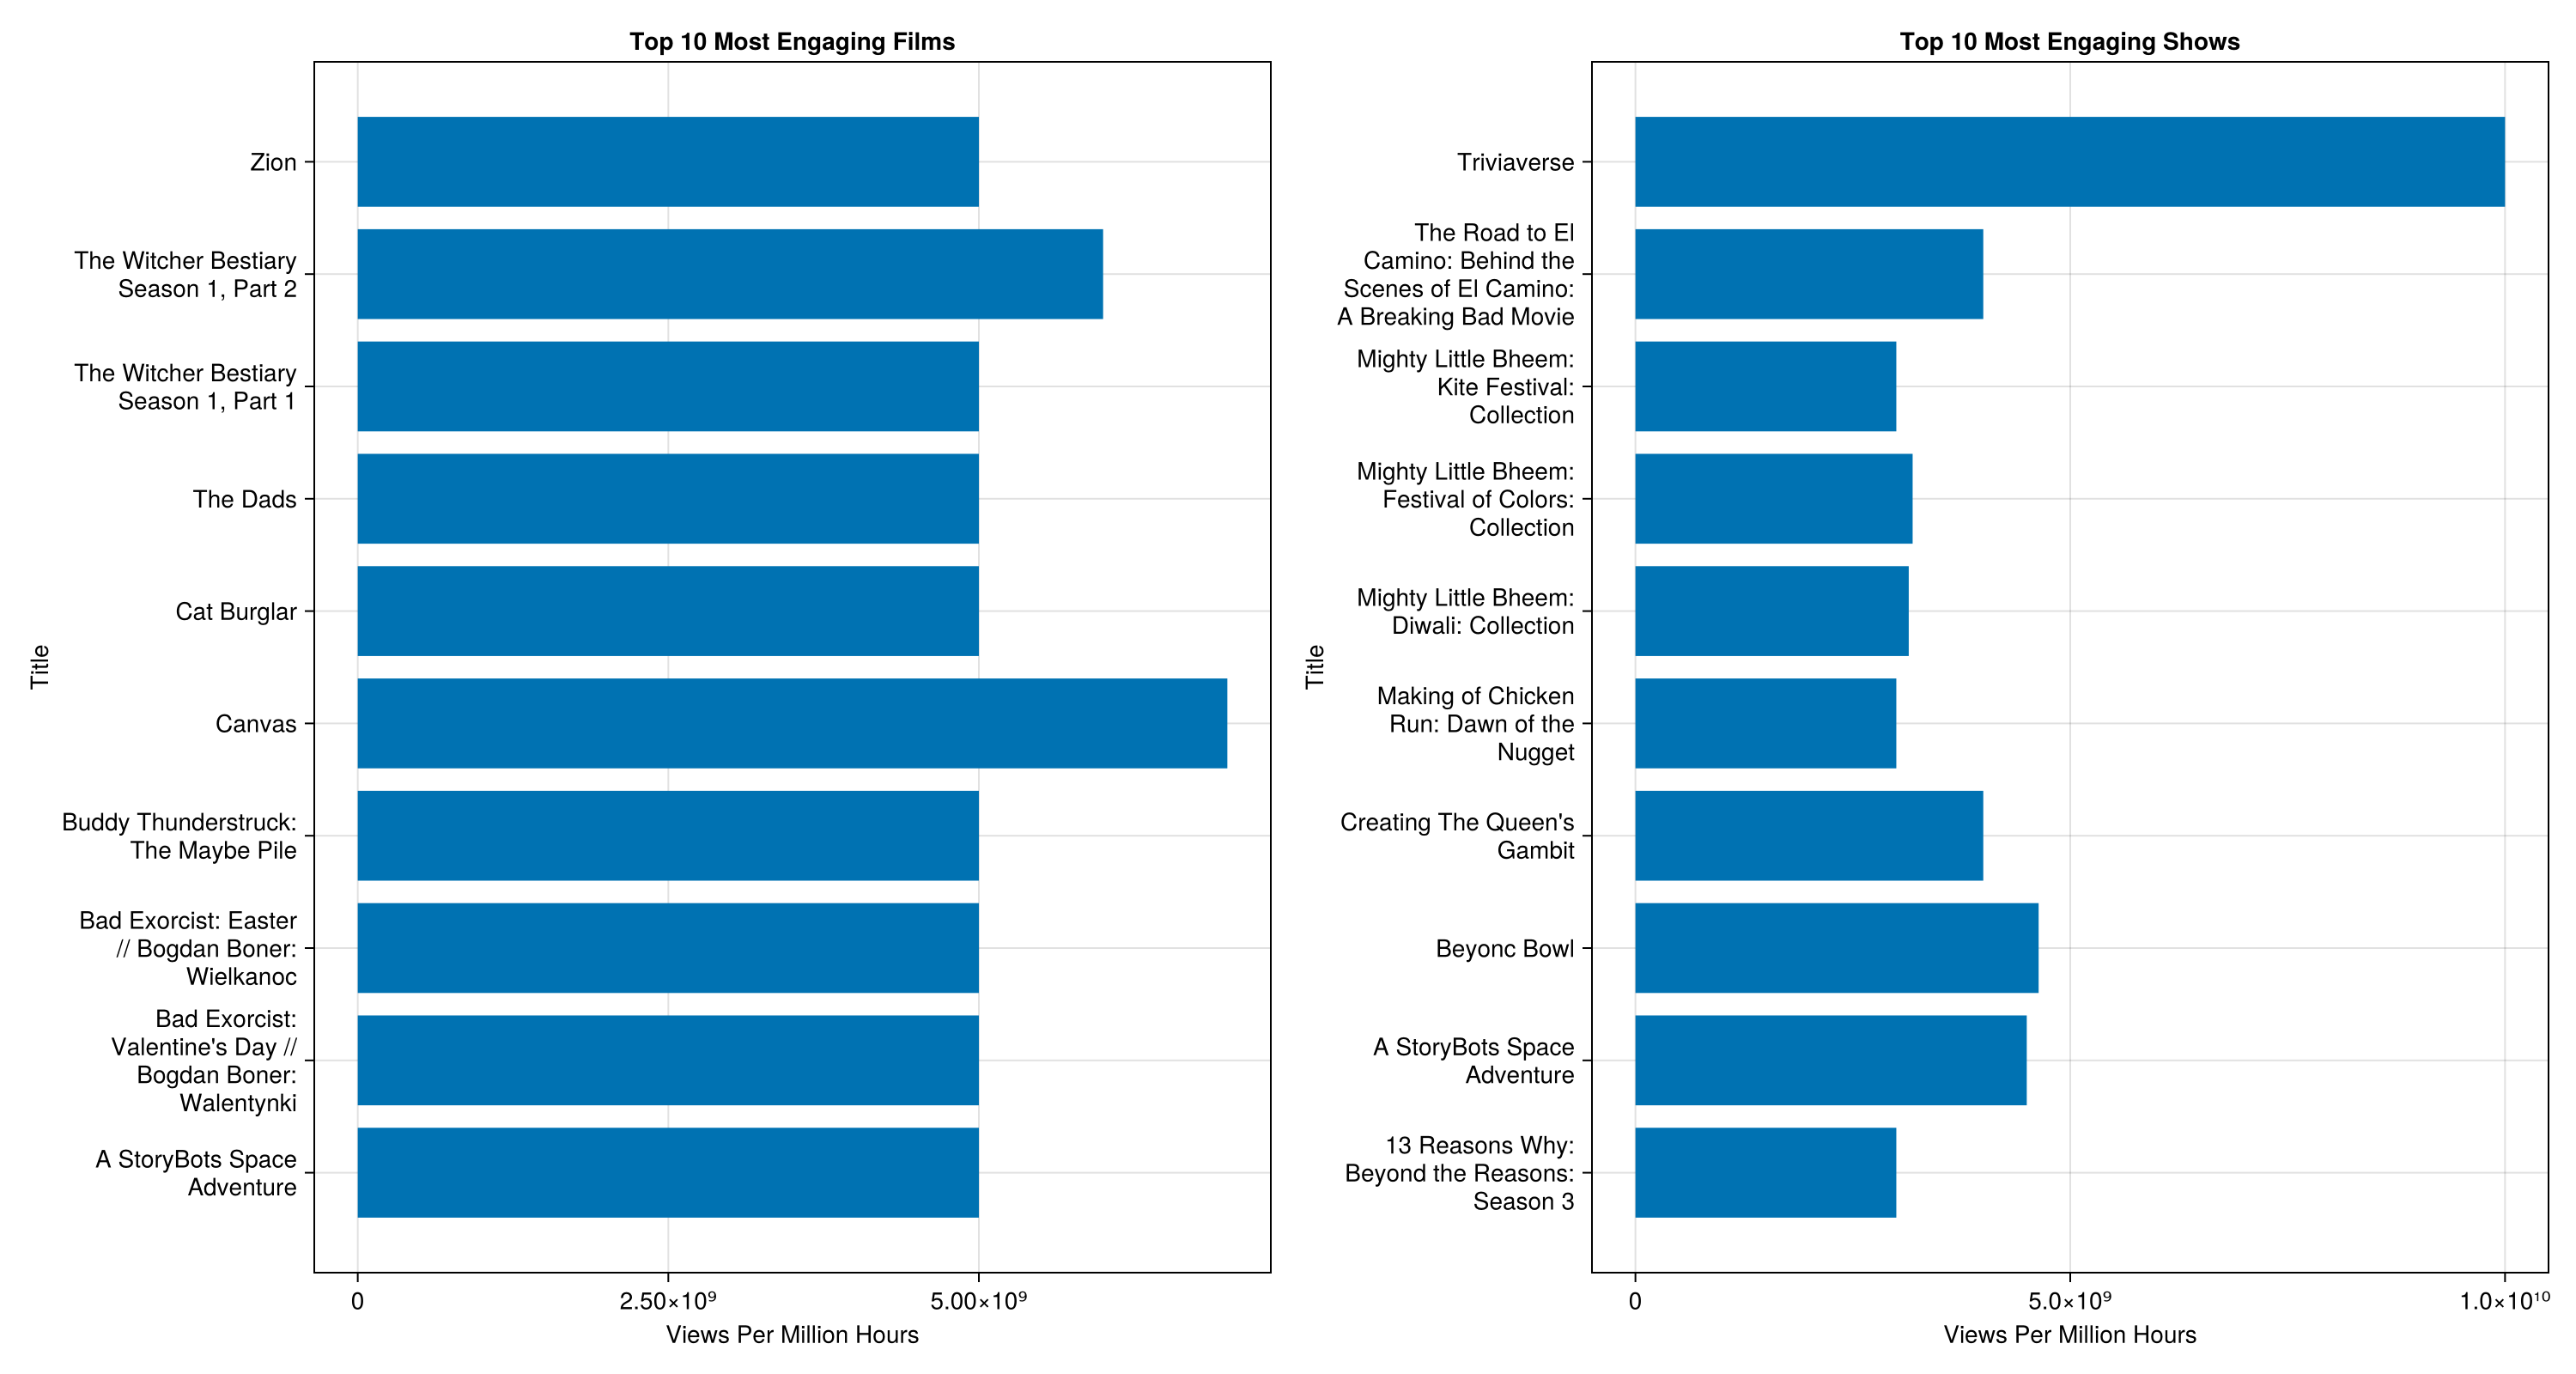

In [19]:
cleanData[!, :ViewsPerHour] = cleanData[!, :Views] ./ (cleanData[!, :"Hours Viewed"] / 1_000_000_000) 

filmData = filter(row -> row.Type == "Film", cleanData) 
showData = filter(row -> row.Type == "Shows", cleanData)

topFilms = sort(filmData, :ViewsPerHour, rev=true) 
topFilms = unique(topFilms, :Title) 
topFilms = topFilms[1:min(10, nrow(topFilms)), :] 

topShows = sort(showData, :ViewsPerHour, rev=true)
topShows = unique(topShows, :Title) 
topShows = topShows[1:min(10, nrow(topShows)), :]

topFilms[!, :WrappedTitle] = ascii_only.(wrap_text.(topFilms.Title, width=20))
topShows[!, :WrappedTitle] = ascii_only.(wrap_text.(topShows.Title, width=20))

filmData[!, :HoursViewedMillions] = filmData[!, :"Hours Viewed"] ./ 1e6
filmData[!, :Highlight] .= "Other Film"
filmData[in.(filmData.Title, Ref(topFilms.Title)), :Highlight] .= "Top Film"

showData[!, :HoursViewedMillions] = showData[!, :"Hours Viewed"] ./ 1e6
showData[!, :Highlight] .= "Other Show"
showData[in.(showData.Title, Ref(topShows.Title)), :Highlight] .= "Top Show"

# Visualization of shows popularity films.
plt1 = AlgebraOfGraphics.data(topFilms) * mapping(   
    :WrappedTitle,       
    :ViewsPerHour, 
    color = :Type 
) * visual(BarPlot, direction = :x)

plt2 = AlgebraOfGraphics.data(topShows) * mapping(   
    :WrappedTitle,       
    :ViewsPerHour, 
    color = :Type 
) * visual(BarPlot, direction = :x)

fig = Figure(size=(1500, 800))

ax1 = draw!(fig[1, 1], plt1, axis=(; 
    title = "Top 10 Most Engaging Films", 
    ylabel="Title", xlabel="Views Per Million Hours"))

ax2 = draw!(fig[1, 2], plt2, axis=(; 
    title = "Top 10 Most Engaging Shows", 
    ylabel="Title", xlabel="Views Per Million Hours"))

fig

Here we try not just to see raw popularity but efficiency as well, that is how much audience attention a title captures relative to time watched.
So Some titles may not dominate total hours, but they generate very high engagement. This would mean\suggest strong audience pull in shorter windows.

Engagement tells us which titles people lean in to watch actively, not just what’s playing in the background.

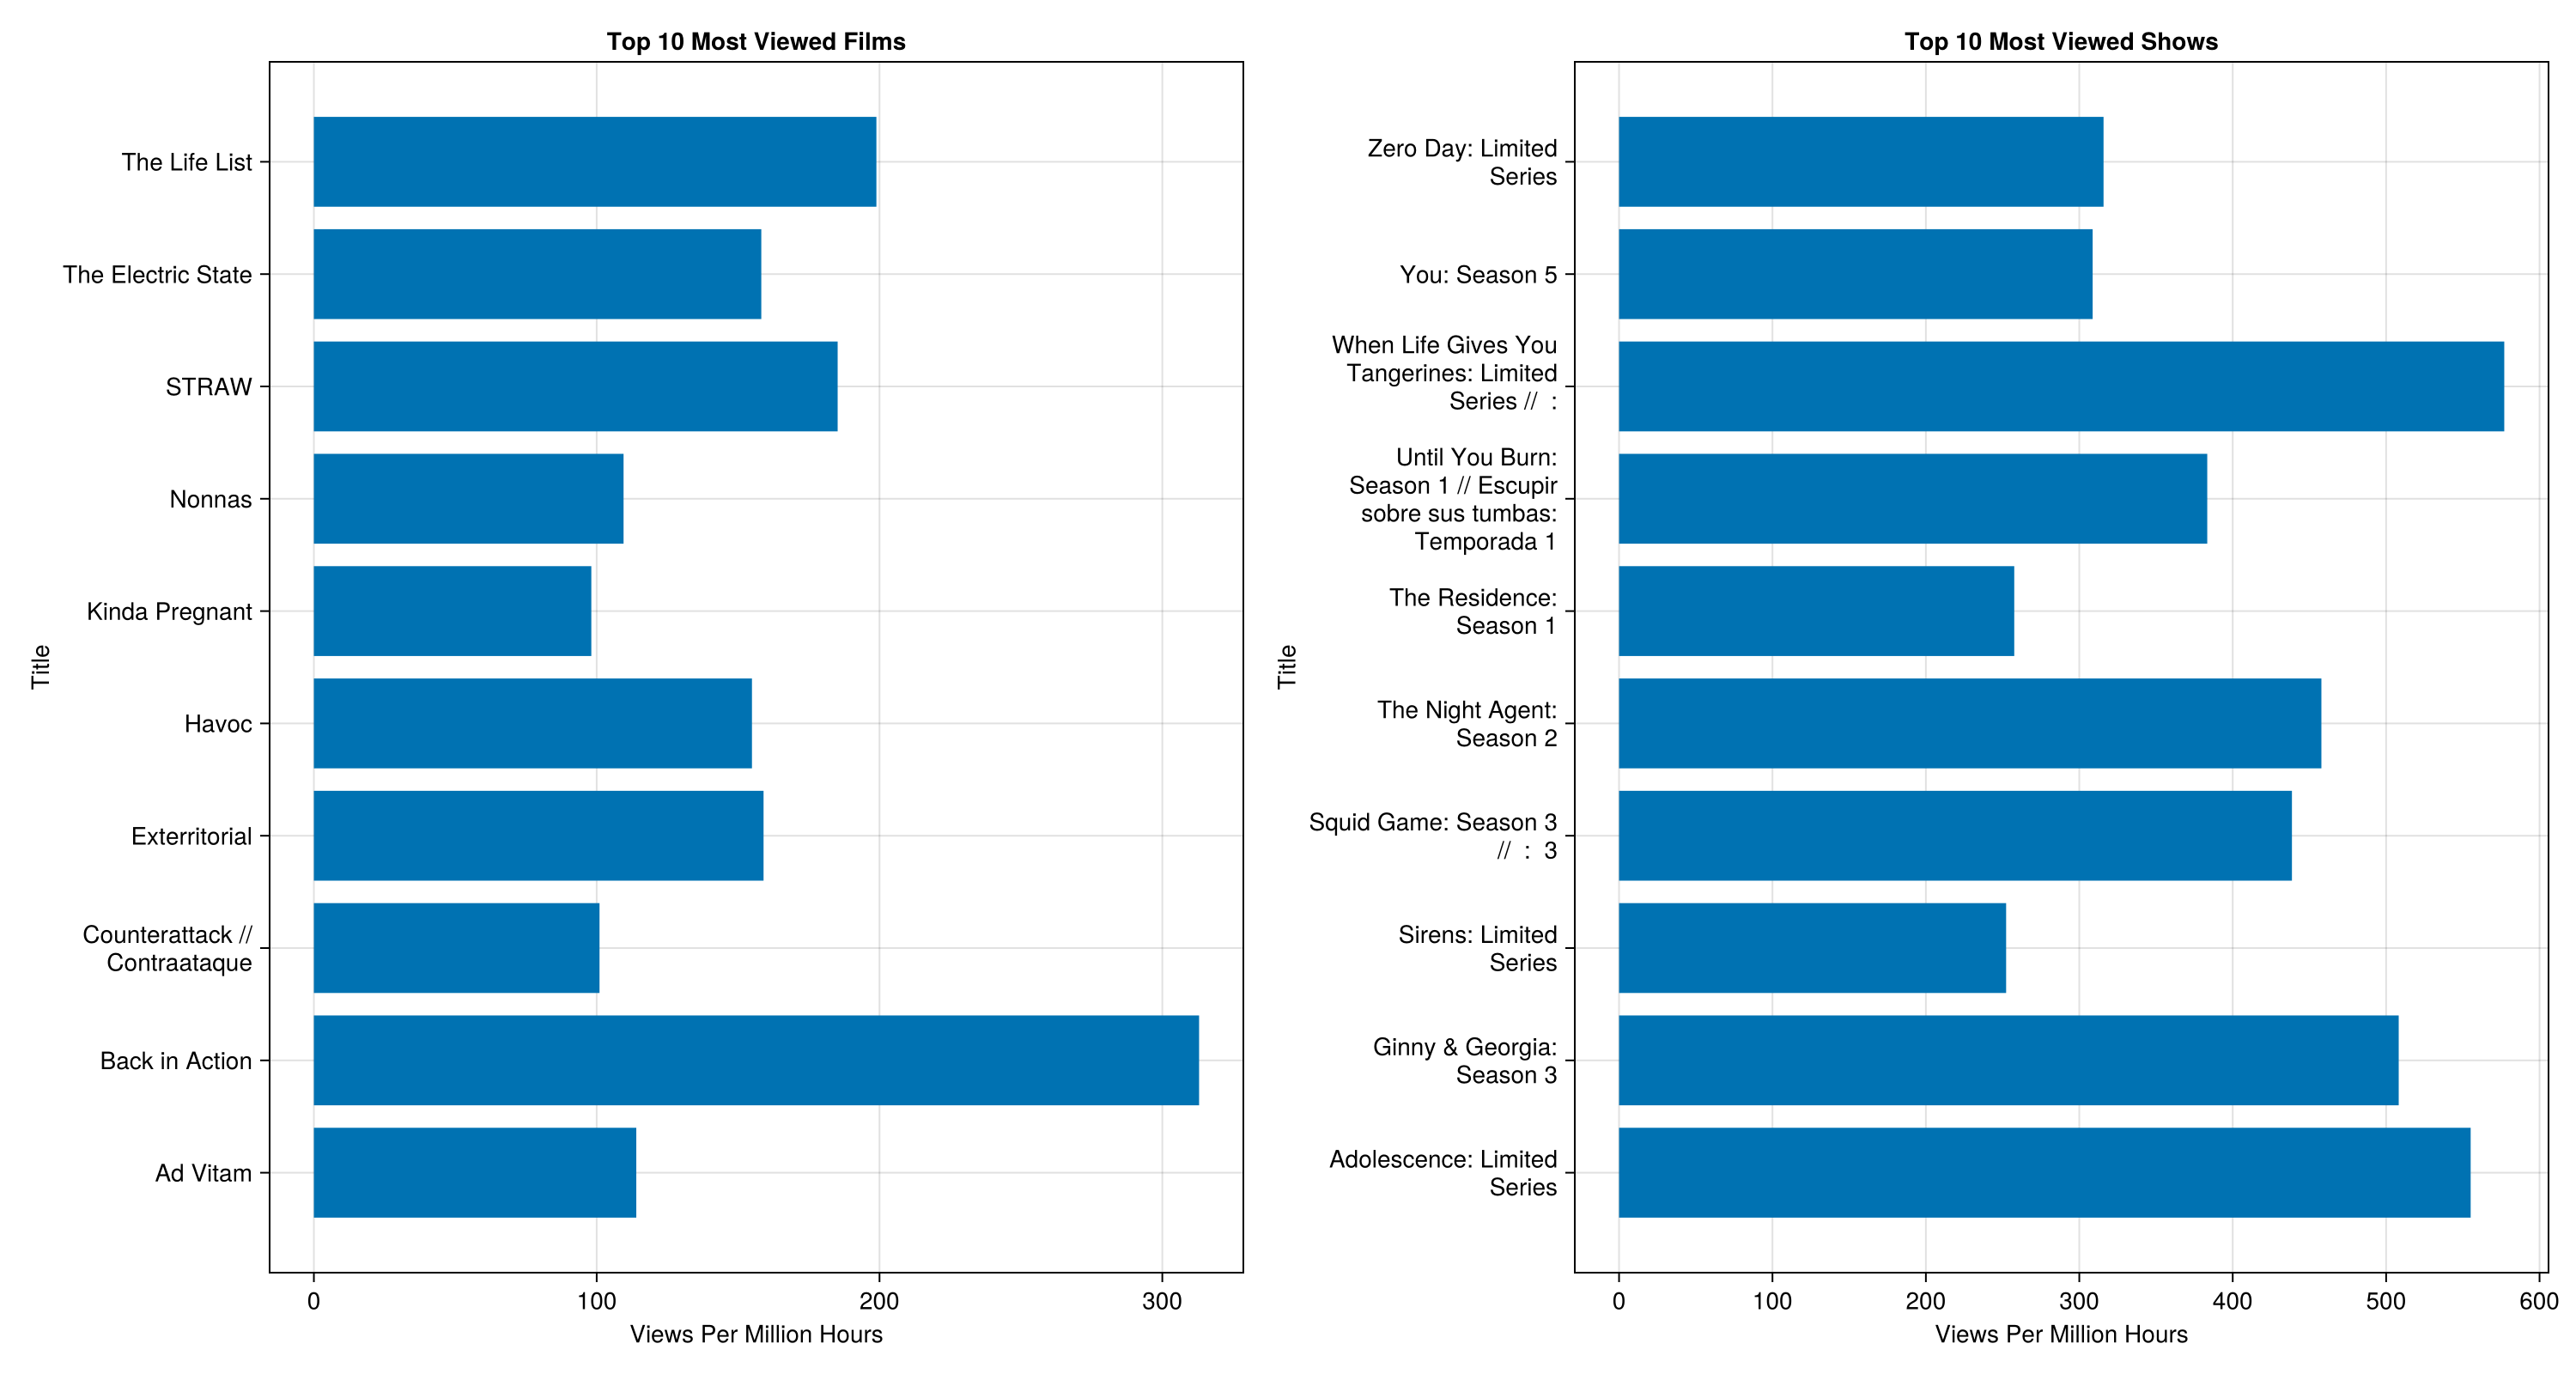

In [20]:
# Top Films by Hours Viewed
filmDataYear = filter(:ReleaseDate => d -> d >= Date(2025,1,1) && d <= Date(2025,6,30), filmData)
showDataYear = filter(:ReleaseDate => d -> d >= Date(2025,1,1) && d <= Date(2025,6,30), showData)

topFilms_hours = sort(filmDataYear, :"Hours Viewed", rev=true)
topFilms_hours = unique(topFilms_hours, :Title)
topFilms_hours = topFilms_hours[1:min(10, nrow(topFilms_hours)), :]

# Top Shows by Hours Viewed
topShows_hours = sort(showDataYear, :"Hours Viewed", rev=true)
topShows_hours = unique(topShows_hours, :Title)
topShows_hours = topShows_hours[1:min(10, nrow(topShows_hours)), :]

topFilms_hours[!, :WrappedTitle] = ascii_only.(wrap_text.(topFilms_hours.Title, width=20))
topShows_hours[!, :WrappedTitle] = ascii_only.(wrap_text.(topShows_hours.Title, width=20))

topFilms_hours[!, :HoursViewedMillions] = topFilms_hours[!, :"Hours Viewed"] ./ 1e6
topShows_hours[!, :HoursViewedMillions] = topShows_hours[!, :"Hours Viewed"] ./ 1e6

# Visualization of most watched films
plt1 = AlgebraOfGraphics.data(topFilms_hours) * mapping(   
    :WrappedTitle,       
    :HoursViewedMillions, 
    color = :Type 
) * visual(BarPlot, direction = :x)

plt2 = AlgebraOfGraphics.data(topShows_hours) * mapping(   
    :WrappedTitle,       
    :HoursViewedMillions, 
    color = :Type 
) * visual(BarPlot, direction = :x)

fig = Figure(size=(1500, 800))

ax1 = draw!(fig[1, 1], plt1, axis=(; 
    title = "Top 10 Most Viewed Films", 
    ylabel="Title", xlabel="Views Per Million Hours"))

ax2 = draw!(fig[1, 2], plt2, axis=(; 
    title = "Top 10 Most Viewed Shows", 
    ylabel="Title", xlabel="Views Per Million Hours"))

fig

Another poin of view we can take is on  the absolute watch time. This is the metric of scale and broad reach.
Here we see the shows/films that most people watched.
These are the heavyweights  Netflix’s traffic drivers. But note: big doesn’t always mean engaging.

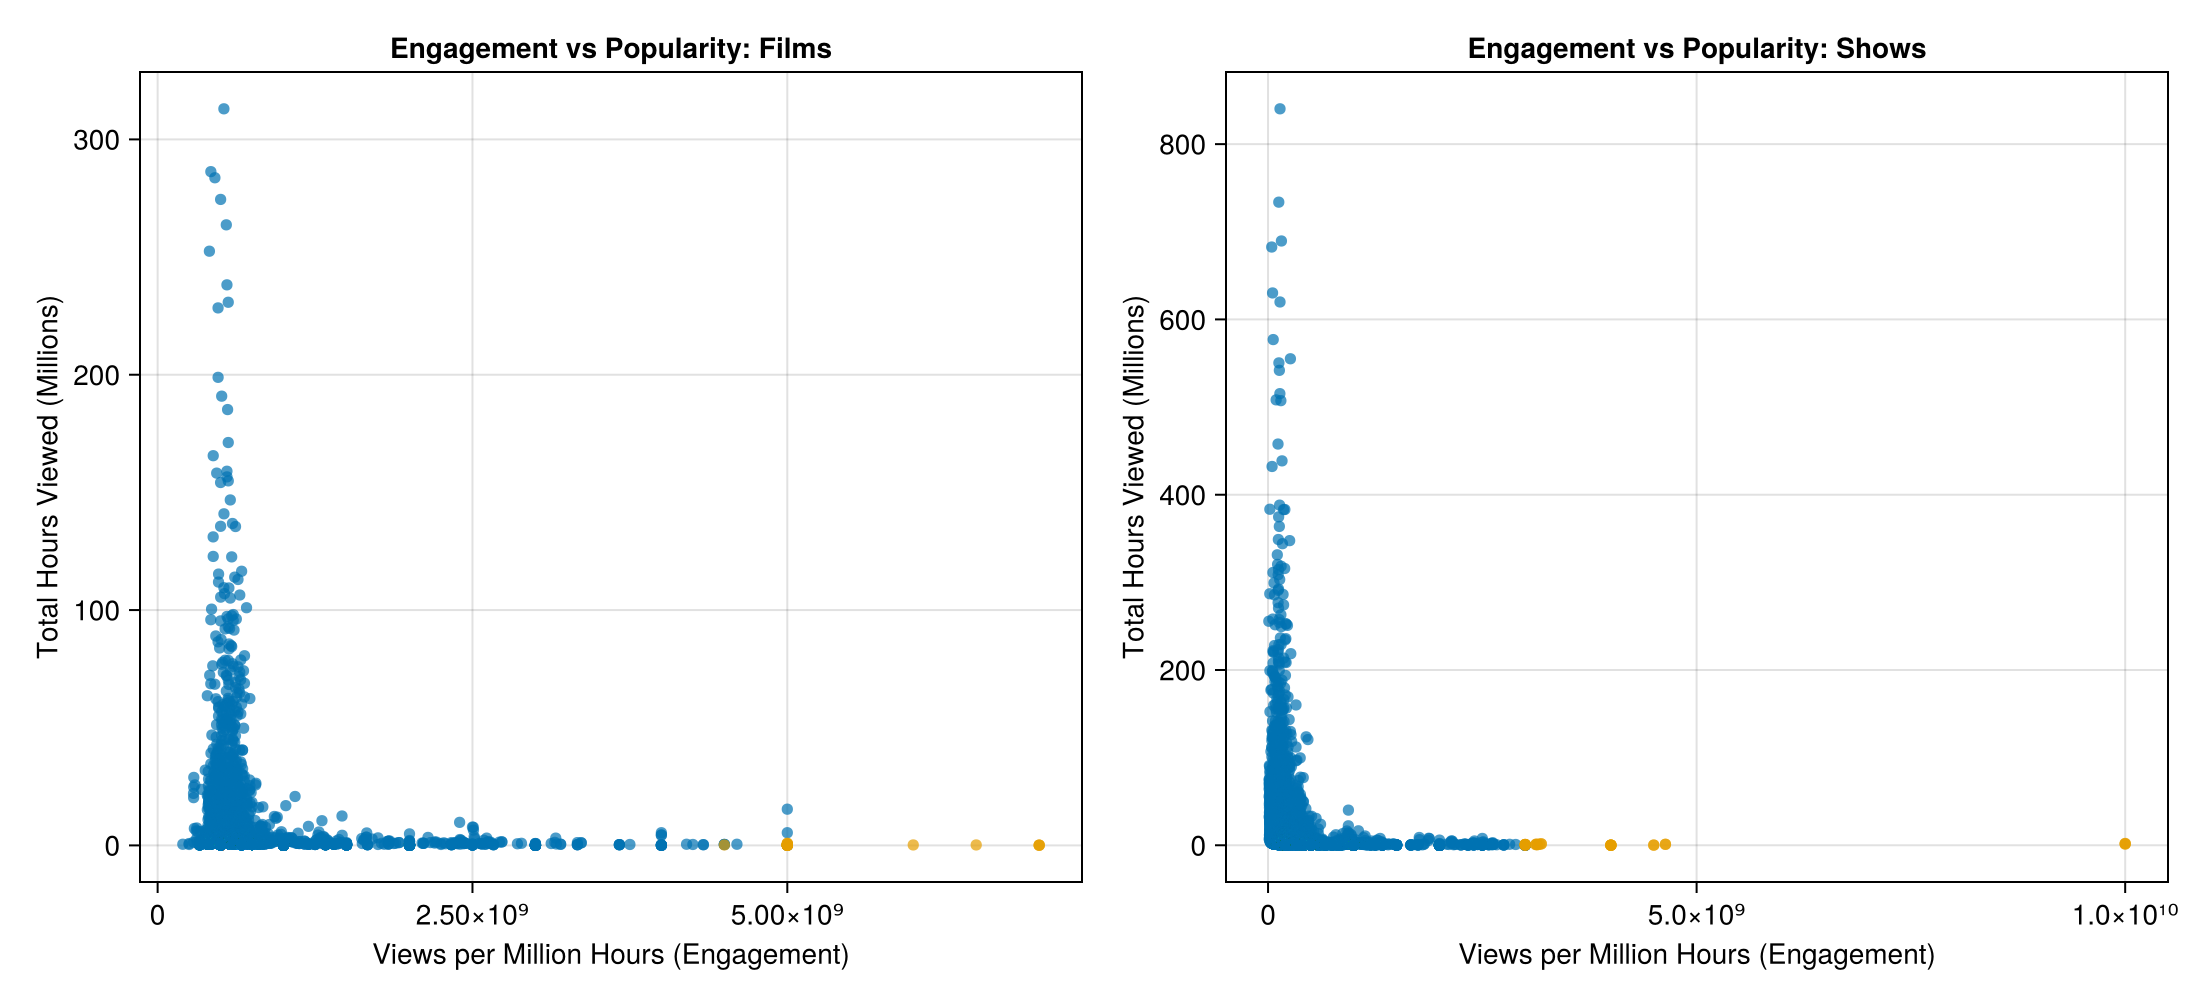

In [21]:
#Mark rows that are in top 10 engaging
plt1 = AlgebraOfGraphics.data(filmData) * mapping(
    :ViewsPerHour,
    :HoursViewedMillions,
    color = :Highlight
) * visual(Scatter, markersize=8, alpha=0.7)

plt2 = AlgebraOfGraphics.data(showData) * mapping(
    :ViewsPerHour,
    :HoursViewedMillions,
    color = :Highlight
) * visual(Scatter, markersize=8, alpha=0.7)

fig = Figure(size=(1100, 500))

draw!(fig[1, 1], plt1, axis=(;
    title="Engagement vs Popularity: Films",
    xlabel="Views per Million Hours (Engagement)",
    ylabel="Total Hours Viewed (Millions)"))

draw!(fig[1, 2], plt2, axis=(;
    title="Engagement vs Popularity: Shows",
    xlabel="Views per Million Hours (Engagement)",
    ylabel="Total Hours Viewed (Millions)"))

fig

This shows the relationship between titles with high engagement vs those with high total views.

Clearly from this we can see two categories:

    1. we can see blockbusters with massive hours but average engagement.
    
    2. Buzzy shows with very high engagement but smaller total hours.

### Seasonality in viewership.

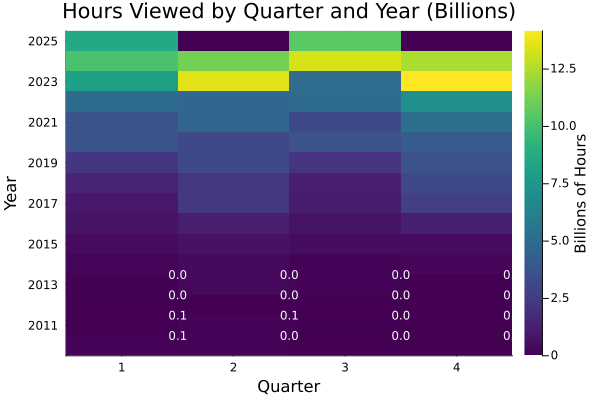

In [22]:
cleanData[!, :Year] = year.(cleanData[!, :ReleaseDate])
cleanData[!, :Quarter] = Dates.quarter.(cleanData[!, :ReleaseDate])

quarterlyHeatmap = combine(groupby(cleanData, [:Year, :Quarter]), 
                           :"Hours Viewed" => sum => :TotalHours)

heatmapData = unstack(quarterlyHeatmap, :Quarter, :Year, :TotalHours, fill=0)

#Convert to matrix for heatmap
heatmapMatrix = Matrix(heatmapData[:, 2:end]) ./ 1e9 

p23 = Plots.heatmap(string.(1:4), string.(names(heatmapData)[2:end]), heatmapMatrix',
            title="Hours Viewed by Quarter and Year (Billions)",
            xlabel="Quarter", ylabel="Year",
            color=:viridis, colorbar_title="Billions of Hours")

for i in 1:size(heatmapMatrix, 1)
    for j in 1:size(heatmapMatrix, 2)
        annotate!(j, i, Plots.text(round(heatmapMatrix[i, j], digits=1), 8, :white))
    end
end

display(p23)

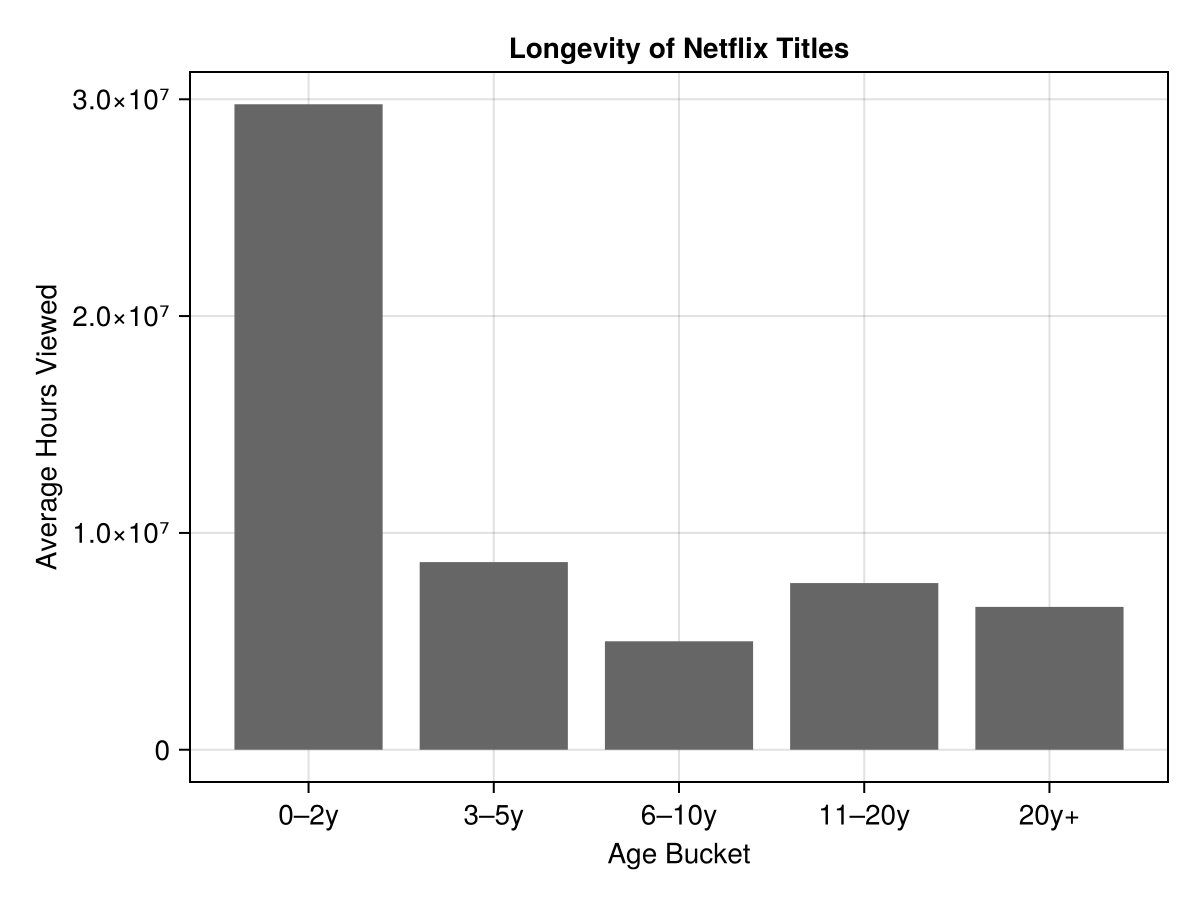

In [23]:
cleanData[!, :age] = year(today()) .- cleanData.ReleaseYear

cleanData[!, :age_bucket] = cut(
    cleanData.age,
    [0, 2, 5, 10, 20, maximum(cleanData.age)], 
    labels=["0–2y", "3–5y", "6–10y", "11–20y", "20y+"]
)

longevity_summary = combine(
    groupby(cleanData, :age_bucket),
    :"Hours Viewed" => mean => :avg_hours,
    :"Hours Viewed" => sum  => :total_hours,
    :"Views"        => mean => :avg_views
)
longevity_summary

#Visualization.
plt = AlgebraOfGraphics.data(longevity_summary) * mapping(
    :age_bucket,     
    :avg_hours        
) * visual(BarPlot)

fig = draw(plt, 
    axis=(
        title="Longevity of Netflix Titles",
        xlabel="Age Bucket", 
        ylabel="Average Hours Viewed"
    )
)
fig 

Here we compare recent vs older releases.Most titles peak early and decay, but some older titles remain evergreen, driving the long tail.
It’s not just the new releases Netflix benefits from classics that continue to pull steady viewership years later.